In [ ]:
#1.修改前處理圖片儲存x的.h5的字典，x_train->x

In [17]:

import h5py as h5
import numpy as np
import tensorflow as tf
from keras import layers,metrics
from keras.layers import Dropout,Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from keras.models import Model, load_model,Sequential
from keras.preprocessing import image
from keras.utils import layer_utils
from keras.utils.data_utils import get_file
from keras.applications.imagenet_utils import preprocess_input
from IPython.display import SVG
from matplotlib.pyplot import imshow
import scipy.io
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [29]:
def Read_TrainData():
    with h5.File("D:/DLmidterm/train.h5",'r') as file:
        x_train=file.get("x").value
    data=scipy.io.loadmat("train.mat")
    y_train,y_onehot=data['y'],data['y_onehot']
    y_onehot=y_onehot.reshape((5000,4,19))
    return x_train,y_onehot
def Validation_Data(x_train,y_onehot,ratio=0.25):
    X_train, X_test, y_train, y_test = train_test_split(x_train, y_onehot, test_size=ratio, random_state=1)
    return X_train, X_test, y_train, y_test

def Deal_With_Label(data): #將label轉成[array(第一碼),array(第二碼),array(第三碼),array(第四碼)]
    label=[]
    for num in range(4):
        data_array=np.zeros((data.shape[0],19))
        for i in range(data.shape[0]):
            data_array[i]=data[i][num]
        label.append(data_array)
    return label
x_train,y_onehot=Read_TrainData()
X_train, X_test, y_train, y_test=Validation_Data(x_train,y_onehot,0.25)
y_train=Deal_With_Label(y_train)
y_test=Deal_With_Label(y_test)

print(y_train[0])
print(y_test[0]) ##y_train[0]=[422T] y_test[0]=[C29T]

C:\Users\benzener\anaconda3\envs\tf-cpu\lib\site-packages\ipykernel_launcher.py:3: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  This is separate from the ipykernel package so we can avoid doing imports until


[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [45]:
#輸入模型與預測圖片和序號，得到圖片預測和解答，用於查看一張圖
def Predict_Label(model,image,num,y_onehot):
    x = np.expand_dims(image,axis=0)
    x=np.argmax(model.predict(x),axis=2)
    print("prdict=",LabelToLetter(x))
    print("answer=",Answer(num,y_onehot))
    plt.imshow(image)
    plt.show()

    
Predict_Label(model2,x1[0],0,y1_onehot)

ValueError: Error when checking input: expected input_32 to have 4 dimensions, but got array with shape (1, 103)

In [60]:
#輸入測試第幾張圖片，得到圖片解答是麼
def Answer(num,y_onehot):
    num=num*4
    arr=np.uint8(np.zeros((4,1)))
    for i in range(4):
        arr[i]=np.argmax(y_onehot[num+i])  
    ans=LabelToLetter(arr)
    return ans


In [ ]:
data_sheet={
        "0":"2",
        "1":"3",
        "2":"4",
        "3":'5',
        "4":'7',
        "5":'9',
        "6":'A',
        "7":'C',
        "8":'F',
        "9":'H',
        "10":'K',
        "11":'M',
        "12":'N',
        "13":'P',
        "14":'Q',
        "15":'R',
        "16":'T',
        "17":'Y',
        "18":'Z'
    }

In [35]:
def LabelToLetter(data):
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    letter=[datasheet[str(i[0])]for i in data]
    return letter
        
# x = np.expand_dims(X_train[5],axis=0)
# x=np.argmax(model.predict(x),axis=2)
# print(LabelToLetter(x))
# imshow(X_train[5])


In [43]:
x = np.expand_dims(x1[0],axis=0)
x=np.argmax(model2.predict(x),axis=2)
print(LabelToLetter(x))
imshow(x1[0])

ValueError: Error when checking input: expected input_32 to have 4 dimensions, but got array with shape (1, 103)

In [259]:
model.save('D:/DLmidterm/WithoutDropout.h5')

In [32]:
model2=load_model('D:/DLmidterm/WithoutDropout.h5',compile=False)
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#train_history=model2.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=6)

['R', 'A', '5', 'A']


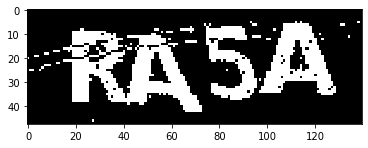

In [12]:
from PIL import Image
# x1=np.array(Image.open('D:/DLmidterm/owntestdealed/0.jpg'))
# x=np.array(Image.fromarray(x1).resize((140,48)))
x = np.expand_dims(x1[2],axis=0)
x=np.argmax(model2.predict(x),axis=2)
print(LabelToLetter(x))
imshow(x1[2])

In [44]:
data=scipy.io.loadmat('D:/DLmidterm/owntest.mat')
x1,y1,y1_onehot=data["x"],data["y"],data["y_onehot"]
x1[0]


array([array([[[190, 190, 190],
        [175, 175, 175],
        [231, 231, 231],
        ...,
        [205, 205, 205],
        [189, 189, 189],
        [158, 158, 158]],

       [[194, 194, 194],
        [216, 216, 216],
        [211, 211, 211],
        ...,
        [240, 240, 240],
        [234, 234, 234],
        [234, 234, 234]],

       [[190, 190, 190],
        [163, 163, 163],
        [240, 240, 240],
        ...,
        [182, 182, 182],
        [198, 198, 198],
        [237, 237, 237]],

       ...,

       [[237, 237, 237],
        [192, 192, 192],
        [187, 187, 187],
        ...,
        [208, 208, 208],
        [211, 211, 211],
        [204, 204, 204]],

       [[222, 222, 222],
        [245, 245, 245],
        [211, 211, 211],
        ...,
        [196, 196, 196],
        [209, 209, 209],
        [191, 191, 191]],

       [[225, 225, 225],
        [214, 214, 214],
        [175, 175, 175],
        ...,
        [172, 172, 172],
        [189, 189, 189],
        [199, 199

In [18]:
y11=Deal_With_Label(y1_onehot)

In [48]:
#這是用於測試集

##輸入模型與檔案名稱，count是map的range，看預測
def Predict_SeriesLabel(model,name,count):
    with h5.File("D:/imgdata/"+str(name)+'.h5','r') as file:
        x=file.get("x").value
    data=scipy.io.loadmat(str(name)+".mat")
    y_test,y_onehot=data['y'],data['y_onehot']
    y_onehot=y_onehot.reshape((y_onehot.shape[0],4,19))
    img=x[0][count]
    x = np.expand_dims(img,axis=0)
    x = np.argmax(model.predict(x),axis=2)
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt=[datasheet[str(i[0])]for i in x] #預測為['A','B','C','D']
    s=count*4
    arr=np.uint8(np.zeros((4,1)))
    for i in range(4):
        arr[i]=(np.argmax(y_onehot[s+i]))  
    ans=[datasheet[str(i[0])]for i in arr] #答案為['A','B','C','D']
    fouracc=0
    for ind,letter in enumerate(pdt):
        if letter==ans[ind]:
            fouracc+=1
    if pdt==ans:
            imgacc=1
    return imgacc,fouracc
    
def TestData(model):
    with h5.File("D:/imgdata/test.h5",'r') as file:
        x_test=file.get("x_test").value
    data=scipy.io.loadmat("train.mat")
    y_test,y_onehot=data['y'],data['y_onehot']
    y_onehot=y_onehot.reshape((3000,4,19))
    for i in range(40):
        Predict_Label(model,x_test[i],i,y_onehot)
    return x_test,y_onehot

def Predict_Label(model,image,num,y_onehot):
    x = np.expand_dims(image,axis=0)
    x=np.argmax(model.predict(x),axis=2)
    print("prdict=",LabelToLetter(x))
    print("answer=",Answer(num,y_onehot))
    plt.imshow(image)
    plt.show()

#輸入測試第幾張圖片，得到圖片解答是麼
def Answer(num,y_onehot):
    num=num*4
    arr=np.uint8(np.zeros((4,1)))
    for i in range(4):
        arr[i]=np.argmax(y_onehot[num+i])  
    ans=LabelToLetter(arr)
    return ans

    
    

In [49]:
Predict_SeriesLabel(model2,owntest,1)

NameError: name 'owntest' is not defined

In [258]:

X_in=Input((48,140,3))
X=X_in
X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=AveragePooling2D(pool_size=(2,2))(X)
X=Flatten()(X)
X=[Dense(19, name='digit1', activation='softmax')(X),
              Dense(19, name='digit2', activation='softmax')(X),
              Dense(19, name='digit3', activation='softmax')(X),
              Dense(19, name='digit4', activation='softmax')(X)]
model=Model(inputs=X_in,outputs=X)
model.summary()
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
train_history=model.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=6)

Model: "model_29"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_32 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_89 (Conv2D)              (None, 48, 140, 8)   1952        input_32[0][0]                   
__________________________________________________________________________________________________
batch_normalization_86 (BatchNo (None, 48, 140, 8)   32          conv2d_89[0][0]                  
__________________________________________________________________________________________________
activation_86 (Activation)      (None, 48, 140, 8)   0           batch_normalization_86[0][0]     
___________________________________________________________________________________________

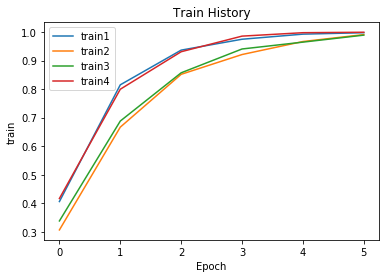

In [203]:
def show_train_history(train_history,train1,train2,train3,train4 ):

    plt.plot(train_history.history[train1])

    plt.plot(train_history.history[train2])

    plt.plot(train_history.history[train3])
    
    plt.plot(train_history.history[train4])
    plt.title('Train History')

    plt.ylabel('train')

    plt.xlabel('Epoch')

    plt.legend(['train1','train2','train3','train4'], loc='upper left')

    plt.show()

show_train_history(train_history, 'digit1_accuracy', 'digit2_accuracy','digit3_accuracy', 'digit4_accuracy')

In [223]:
X_in=Input((48,140,3))
X=X_in
X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Dropout(0.1)(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Dropout(0.1)(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=AveragePooling2D(pool_size=(2,2))(X)
X=Flatten()(X)
X=[Dense(19, name='digit1', activation='softmax')(X),
              Dense(19, name='digit2', activation='softmax')(X),
              Dense(19, name='digit3', activation='softmax')(X),
              Dense(19, name='digit4', activation='softmax')(X)]
model1=Model(inputs=X_in,outputs=X)
model1.summary()
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
train_history=model1.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=6)

Model: "model_28"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_31 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_83 (Conv2D)              (None, 48, 140, 8)   1952        input_31[0][0]                   
__________________________________________________________________________________________________
batch_normalization_80 (BatchNo (None, 48, 140, 8)   32          conv2d_83[0][0]                  
__________________________________________________________________________________________________
activation_80 (Activation)      (None, 48, 140, 8)   0           batch_normalization_80[0][0]     
___________________________________________________________________________________________

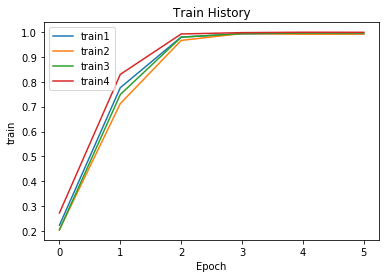

In [256]:
show_train_history(train_history, 'digit1_accuracy', 'digit2_accuracy','digit3_accuracy', 'digit4_accuracy')

In [1]:
show_train_history(train_history, 'val_digit1_accuracy', 'val_digit2_accuracy','val_digit3_accuracy', 'val_digit4_accuracy')

NameError: name 'show_train_history' is not defined

In [7]:
import multiprocess as mp
import numpy as np


if __name__=='__main__':
    # Get all worker processes
    cores = mp.cpu_count()

    # Start all worker processes
    pool = mp.Pool(processes=cores)
    x1 = list(range(5))
    y1 = list(range(5))

    tasks = [(model,test,i) for i in range(10)]
    res=pool.starmap(Predict_SeriesLabel,tasks)
    accuracy=np.sum(np.asarray(tasks),axis=0)
    sigma=np.asarray(accuracy)
    imgaccuracy=sigma[0]/x.shape[1]
    fourwordccuracy=sigma[1]/x.shape[1]
    print('')
    

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


In [16]:
np.sum(sigma,axis=0)

array([50, 50])